In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,StandardScaler,OneHotEncoder

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE,ADASYN

In [4]:
# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


#Evaluation metrics
from sklearn.metrics import accuracy_score,roc_auc_score,f1_score,precision_score,recall_score,r2_score,mean_absolute_error
from sklearn.metrics import confusion_matrix,classification_report

In [5]:
#The dataset was loaded into a Pandas DataFrame for analysis and preprocessing.

kidney_df=pd.read_csv(r'E:\DS\PROJECTS\MULTIPLE_DISEASE_PREDICTION\MULTIPLE_DISEASE_PREDICTION\kidney_disease - kidney_disease.csv')
kidney_df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [6]:
kidney_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [7]:
kidney_df.describe(include='all')

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,248,335,396,396,...,330,295,270,398,398,398,399,399,399,400
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,...,43,90,46,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,normal,normal,notpresent,notpresent,...,52,9800,5.2,no,no,no,good,no,no,ckd
freq,NaN,NaN,NaN,NaN,NaN,NaN,201,259,354,374,...,21,11,18,251,261,364,317,323,339,250
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
kidney_df.duplicated().sum()

np.int64(0)

In [9]:
kidney_df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [10]:
# Basic data inspection was performed to:
#   * Understand data types
#   * Identify missing values
#   * Analyze numerical feature distribution

In [11]:
kidney_df=kidney_df.drop('id',axis=1)

#The id column was removed since it does not contribute to disease prediction.

In [12]:
kidney_df['classification'].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [13]:
(kidney_df.isnull().sum()/len(kidney_df))*100

age                2.25
bp                 3.00
sg                11.75
al                11.50
su                12.25
rbc               38.00
pc                16.25
pcc                1.00
ba                 1.00
bgr               11.00
bu                 4.75
sc                 4.25
sod               21.75
pot               22.00
hemo              13.00
pcv               17.50
wc                26.25
rc                32.50
htn                0.50
dm                 0.50
cad                0.50
appet              0.25
pe                 0.25
ane                0.25
classification     0.00
dtype: float64

In [14]:
num_cols=kidney_df.select_dtypes(include=['int64','float64']).columns
categ_cols=kidney_df.select_dtypes(include=['object','string']).columns


In [15]:
#Fill missing values instead of deleting patients.

imputer_num=SimpleImputer(strategy='median')
kidney_df[num_cols]=imputer_num.fit_transform(kidney_df[num_cols])

In [16]:
imputer_categ=SimpleImputer(strategy='most_frequent')
kidney_df[categ_cols]=imputer_categ.fit_transform(kidney_df[categ_cols])

In [17]:
kidney_df=kidney_df.dropna()

In [18]:
kidney_df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [19]:
kidney_df.columns = kidney_df.columns.str.strip()
kidney_df['classification']=kidney_df['classification'].map({'ckd':1,'notckd':0})

#Extra spaces in the target column were removed.
#The target variable was encoded into numeric form:
#1 → CKD
#0 → Not CKD

In [20]:
kidney_df['classification'].value_counts()

classification
1    250
0    150
Name: count, dtype: int64

#### EDA

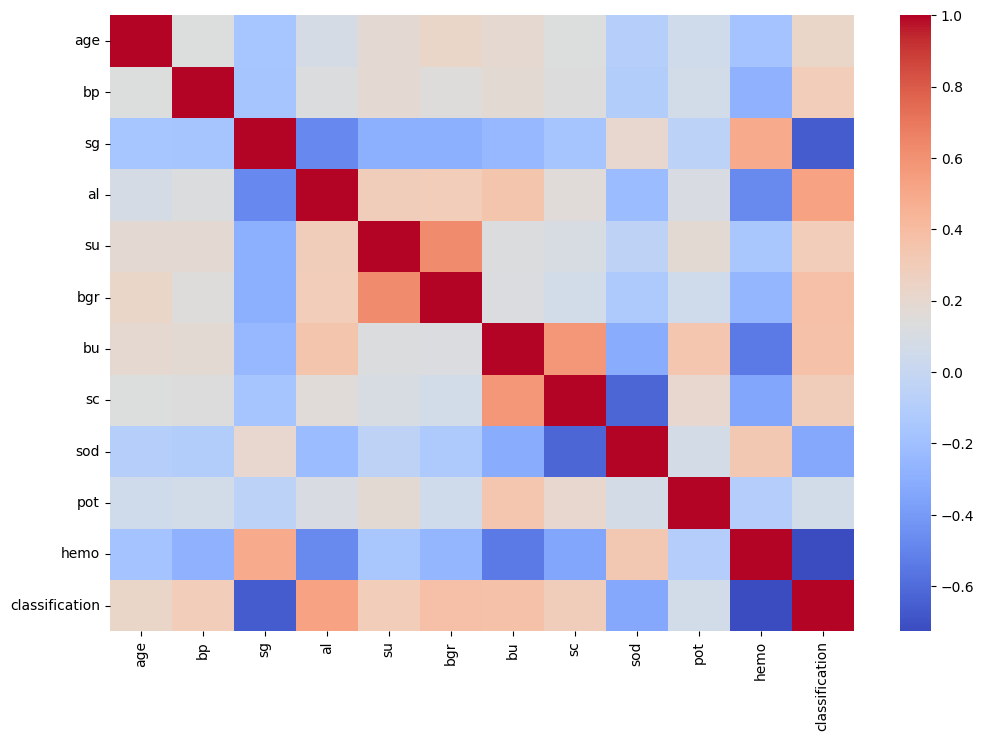

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(kidney_df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.show()

In [22]:
num_df = kidney_df.select_dtypes(include='number')

num_df.corr()['classification'].sort_values(ascending=False)

#Identified most influential features affecting CKD prediction.

classification    1.000000
al                0.531562
bgr               0.379321
bu                0.369393
su                0.294555
bp                0.293693
sc                0.291245
age               0.227842
pot               0.065218
sod              -0.334900
sg               -0.659504
hemo             -0.726368
Name: classification, dtype: float64

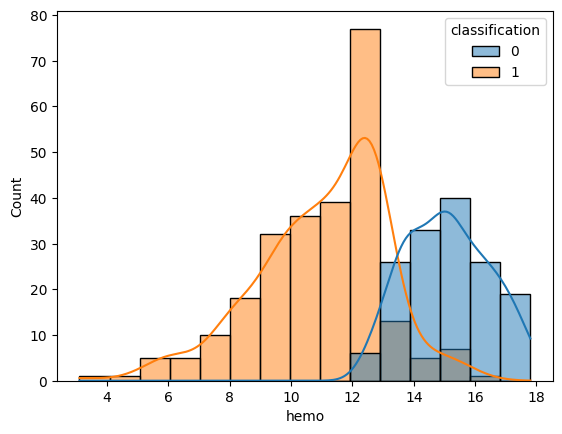

In [23]:
#Visualized feature distribution to check class separability.

sns.histplot(data=kidney_df, x='hemo', hue='classification', kde=True)
plt.show()

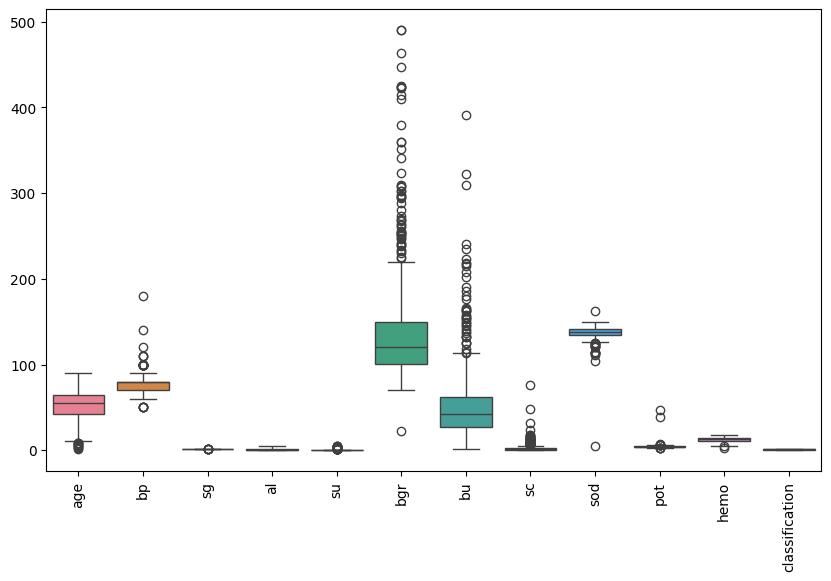

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(data=kidney_df)
plt.xticks(rotation=90)
plt.show()


In [25]:
pd.crosstab(kidney_df['htn'], kidney_df['classification'])

classification,0,1
htn,,
no,150,103
yes,0,147


In [26]:
kidney_df['classification'].value_counts(normalize=True)*100

classification
1    62.5
0    37.5
Name: proportion, dtype: float64

In [27]:
#Categorical variables were converted into numerical format using Label Encoding to make them suitable for
# machine learning models.

LE=LabelEncoder()
for col in categ_cols:
    if col!='classification':
        kidney_df[col]=LE.fit_transform(kidney_df[col])

In [28]:
#Separated independent variables (X) and target variable (y).

X=kidney_df.drop('classification',axis=1)
y=kidney_df['classification']

In [29]:
#Split dataset into:80% training data and 20% testing data

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((320, 24), (80, 24), (320,), (80,))

In [30]:
#Standardized numerical features to improve Logistic Regression performance.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
LG= LogisticRegression(max_iter=100)

LG.fit(X_train_scaled, y_train)
y_pred_LG = LG.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_LG))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_LG))
print("\nClassification Report:\n", classification_report(y_test, y_pred_LG))

#Trained Logistic Regression as baseline linear classifier.

Accuracy: 0.9875

Confusion Matrix:
 [[28  0]
 [ 1 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       1.00      0.98      0.99        52

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [32]:
#Random Forest

RF=RandomForestClassifier()
RF.fit(X_train,y_train)

y_pred_RF=RF.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_RF))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_RF))
print("\nClassification Report:\n", classification_report(y_test, y_pred_RF))

Accuracy: 1.0

Confusion Matrix:
 [[28  0]
 [ 0 52]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [33]:
#XG BOOST

XGB=XGBClassifier()
XGB.fit(X_train,y_train)

y_pred_XGB=XGB.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_XGB))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred_XGB))
print("\nClassification Report:\n", classification_report(y_test,y_pred_XGB))

Accuracy: 0.9875

Confusion Matrix:
 [[28  0]
 [ 1 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       1.00      0.98      0.99        52

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



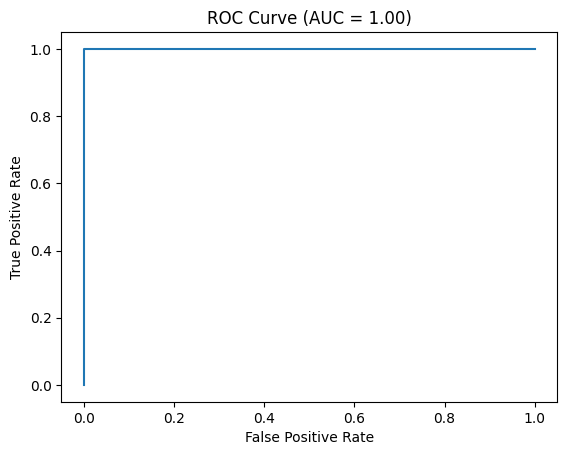

In [34]:
from sklearn.metrics import roc_curve, auc

y_prob = RF.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()


In [35]:
print("ROC-AUC:", roc_auc)

ROC-AUC: 1.0


##### Model	Accuracy
Logistic Regression - 98.75%,
Random Forest - 100%
XGBoost - 98.75%

Random Forest achieved perfect classification on test dataset and was selected as final model.

In [36]:
import pickle
# Save model
with open("kidney_model.pkl", "wb") as file:
    pickle.dump(RF,file) 

In [37]:
# Save scaler
with open("kidney_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [38]:
# Save feature columns
feature_columns_kidney = X.columns.tolist()

with open("kidney_features.pkl", "wb") as file:
    pickle.dump(feature_columns_kidney, file)

##### The Random Forest model achieved the highest performance with 100% accuracy on the test dataset. Important features influencing prediction include hypertension, hemoglobin level, and diabetes. The model demonstrates strong predictive capability for early detection of chronic kidney disease.